[*********************100%***********************]  20 of 20 completed


Dataset successfully loaded: 5220 trading days across 20 tickers.
Training Window (80%): 2006-01-03 to 2022-08-04 (4176 days)
Testing Window  (20%): 2022-08-05 to 2026-10-02 (1044 days)

Screening pairs for cointegration on the training dataset...

=================== STATISTICAL ARBITRAGE PERFORMANCE & HALF-LIFE SUMMARY ===================
        Pair Beta (Hedge) Half-Life (Days) Initial Capital Final Capital Net Profit ($) Return (%)  Total Trades Win Rate (%) Max Drawdown (%)
 MSFT / QCOM       2.3550       112.9 days     $100,000.00   $116,630.94     $16,630.94     16.63%            23       69.57%           -4.21%
  AMD / KLAC       3.2003       128.1 days     $100,000.00   $114,442.76     $14,442.76     14.44%            19       57.89%           -3.97%
 GOOGL / TSM       1.1026       113.3 days     $100,000.00   $105,550.81      $5,550.81      5.55%            21       61.90%           -1.56%
  AMZN / TXN       1.1357        80.6 days     $100,000.00   $104,231.54      $4,231.

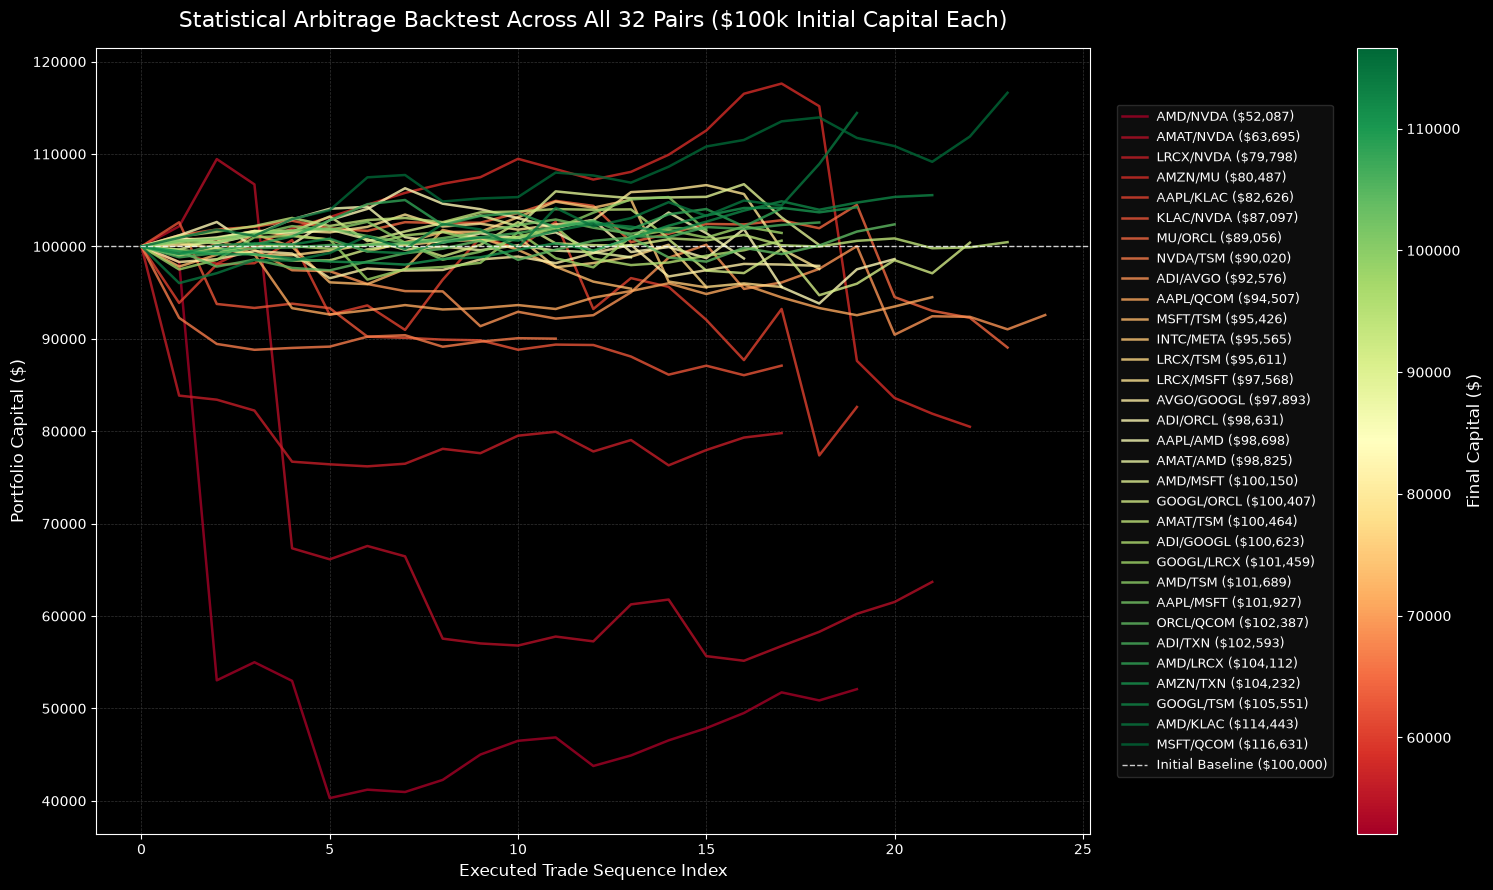

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import yfinance as yf

# Set dark theme styling for high-contrast charts
plt.style.use('dark_background')

# =====================================================================
# 1. FETCH 20 YEARS OF TECH & SEMICONDUCTOR DATA
# =====================================================================
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'ORCL', 'CSCO', 'IBM',
    'NVDA', 'AMD', 'AVGO', 'QCOM', 'INTC', 'TXN', 'MU', 'AMAT',
    'LRCX', 'ADI', 'KLAC', 'TSM'
]

print(f"Downloading historical price data for {len(tickers)} Tech & Semi stocks...")

# auto_adjust=False prevents KeyError across yfinance versions
df_raw = yf.download(tickers, start="2006-01-01", auto_adjust=False)

# Safely extract Adjusted Close price DataFrame
if 'Adj Close' in df_raw.columns:
    df_prices = df_raw['Adj Close'].dropna(how='all')
elif 'Close' in df_raw.columns:
    df_prices = df_raw['Close'].dropna(how='all')
else:
    df_prices = df_raw.xs('Adj Close', axis=1, level=0).dropna(how='all')

# Handle missing trading holiday entries
df_prices = df_prices.ffill().bfill()
print(f"Dataset successfully loaded: {df_prices.shape[0]} trading days across {df_prices.shape[1]} tickers.")


# =====================================================================
# 2. 80 / 20 TRAIN-TEST SPLIT (To Avoid Look-Ahead Bias)
# =====================================================================
split_idx = int(len(df_prices) * 0.80)
train_df = df_prices.iloc[:split_idx]
test_df = df_prices.iloc[split_idx:]

print(f"Training Window (80%): {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} days)")
print(f"Testing Window  (20%): {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} days)\n")


# =====================================================================
# 3. HELPER FUNCTIONS: COINTEGRATION & HALF-LIFE OF MEAN REVERSION
# =====================================================================
def calculate_half_life(spread):
    """
    Calculates half-life using an Ornstein-Uhlenbeck process (AR(1) regression).
    delta_spread(t) = lambda * spread(t-1) + error
    Half-life = -ln(2) / lambda
    """
    spread_lag = spread.shift(1).dropna()
    spread_diff = spread.diff().dropna()
    spread_lag = spread_lag.loc[spread_diff.index]
    
    X = sm.add_constant(spread_lag)
    model = sm.OLS(spread_diff, X).fit()
    lambda_param = model.params.iloc[1]
    
    if lambda_param >= 0:
        return np.inf  # Spread is non-mean-reverting / trending
    
    return -np.log(2) / lambda_param


def analyze_sector_pairs(df, p_threshold=0.05):
    n = df.shape[1]
    keys = df.columns
    results = []
    
    for i in range(n):
        for j in range(i + 1, n):
            s1, s2 = df[keys[i]], df[keys[j]]
            
            # Engle-Granger Cointegration Test
            score, pvalue, _ = coint(s1, s2)
            
            # OLS Regression: S1 = Beta * S2 + Alpha
            X = sm.add_constant(s2)
            model = sm.OLS(s1, X).fit()
            alpha = model.params.iloc[0]
            beta = model.params.iloc[1]
            r_squared = model.rsquared
            
            # Calculate In-Sample Spread and Half-Life
            spread = s1 - (beta * s2 + alpha)
            half_life = calculate_half_life(spread)
            
            results.append({
                'Stock_1': keys[i],
                'Stock_2': keys[j],
                'p_value': pvalue,
                'Cointegrated': pvalue < p_threshold,
                'Alpha': alpha,
                'Beta (Hedge Ratio)': beta,
                'R_Squared': r_squared,
                'Half_Life_Days': half_life
            })
            
    return pd.DataFrame(results)

print("Screening pairs for cointegration on the training dataset...")
pair_stats = analyze_sector_pairs(train_df)
target_pairs = pair_stats[pair_stats['Cointegrated']].sort_values(by='p_value').copy()

if len(target_pairs) == 0:
    print("No pairs passed p < 0.05. Selecting top 10 lowest p-value pairs instead...")
    target_pairs = pair_stats.sort_values(by='p_value').head(10).copy()


# =====================================================================
# 4. MULTI-PAIR BACKTEST ENGINE
# =====================================================================
class MultiPairStatArbBacktest:
    def __init__(self, initial_capital=100000.0, z_entry=2.0, z_exit=0.0, z_stop=3.5):
        self.initial_capital = initial_capital
        self.z_entry = z_entry
        self.z_exit = z_exit
        self.z_stop = z_stop

    def run_pair(self, test_s1, test_s2, beta, alpha, window=60):
        spread = test_s1 - (beta * test_s2 + alpha)
        z_score = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
        
        capital = self.initial_capital
        equity_curve = [capital]
        trades = []
        
        in_pos = False
        pos_type = None
        entry_p1, entry_p2 = 0, 0
        u1, u2 = 0, 0
        
        for i in range(window, len(z_score)):
            z = z_score.iloc[i]
            p1 = test_s1.iloc[i]
            p2 = test_s2.iloc[i]
            
            if not in_pos:
                if z <= -self.z_entry:
                    pos_type = 'LONG_SPREAD'
                    in_pos = True
                elif z >= self.z_entry:
                    pos_type = 'SHORT_SPREAD'
                    in_pos = True
                    
                if in_pos:
                    alloc = capital * 0.15  # Allocate 15% per position
                    u1 = (alloc / 2) / p1
                    u2 = ((alloc / 2) * beta) / p2
                    entry_p1, entry_p2 = p1, p2

            elif in_pos:
                tp = (pos_type == 'LONG_SPREAD' and z >= self.z_exit) or \
                     (pos_type == 'SHORT_SPREAD' and z <= self.z_exit)
                sl = abs(z) >= self.z_stop
                
                if tp or sl:
                    if pos_type == 'LONG_SPREAD':
                        pnl = (u1 * (p1 - entry_p1)) + (u2 * (entry_p2 - p2))
                    else:
                        pnl = (u1 * (entry_p1 - p1)) + (u2 * (p2 - entry_p2))
                        
                    capital += pnl
                    equity_curve.append(capital)
                    trades.append({'pnl': pnl, 'type': pos_type, 'reason': 'SL' if sl else 'TP', 'capital': capital})
                    in_pos = False
                    
        return pd.DataFrame(trades), np.array(equity_curve)


# =====================================================================
# 5. EXECUTE BACKTEST & GENERATE STATS TABLE
# =====================================================================
multi_bt = MultiPairStatArbBacktest(initial_capital=100000.0)

results_list = []
all_equity_curves = []
pair_labels = []

for idx, row in target_pairs.iterrows():
    s1_name, s2_name = row['Stock_1'], row['Stock_2']
    beta, alpha = row['Beta (Hedge Ratio)'], row['Alpha']
    half_life = row['Half_Life_Days']
    
    test_s1, test_s2 = test_df[s1_name], test_df[s2_name]
    trades_df, equity = multi_bt.run_pair(test_s1, test_s2, beta, alpha)
    
    all_equity_curves.append(equity)
    pair_labels.append(f"{s1_name}/{s2_name}")
    
    final_cap = equity[-1]
    net_pnl = final_cap - 100000.0
    ret_pct = (net_pnl / 100000.0) * 100
    n_trades = len(trades_df)
    win_rate = (trades_df['pnl'] > 0).mean() * 100 if n_trades > 0 else 0.0
    
    peak = np.maximum.accumulate(equity)
    max_dd = ((equity - peak) / peak).min() * 100 if len(equity) > 1 else 0.0
    
    results_list.append({
        'Pair': f"{s1_name} / {s2_name}",
        'Beta (Hedge)': beta,
        'Half-Life (Days)': half_life,
        'Initial Capital': 100000.0,
        'Final Capital': final_cap,
        'Net Profit ($)': net_pnl,
        'Return (%)': ret_pct,
        'Total Trades': n_trades,
        'Win Rate (%)': win_rate,
        'Max Drawdown (%)': max_dd
    })

df_all_stats = pd.DataFrame(results_list).sort_values(by='Net Profit ($)', ascending=False)

print("\n=================== STATISTICAL ARBITRAGE PERFORMANCE & HALF-LIFE SUMMARY ===================")
print(df_all_stats.to_string(index=False, formatters={
    'Beta (Hedge)': '{:.4f}'.format,
    'Half-Life (Days)': lambda x: f"{x:.1f} days" if x != np.inf else "N/A (Trending)",
    'Initial Capital': '${:,.2f}'.format,
    'Final Capital': '${:,.2f}'.format,
    'Net Profit ($)': '${:,.2f}'.format,
    'Return (%)': '{:.2f}%'.format,
    'Win Rate (%)': '{:.2f}%'.format,
    'Max Drawdown (%)': '{:.2f}%'.format
}))


# =====================================================================
# 6. ALL-IN-ONE GRADIENT VISUALIZATION (RED-TO-GREEN)
# =====================================================================
final_caps = [eq[-1] for eq in all_equity_curves]
sorted_order = np.argsort(final_caps)

fig, ax = plt.subplots(figsize=(16, 9), facecolor='black')
ax.set_facecolor('black')

cmap = plt.colormaps['RdYlGn']
num_pairs = len(all_equity_curves)

# Plot each pair's equity curve
for rank, sim_idx in enumerate(sorted_order):
    color_val = rank / max(1, (num_pairs - 1))
    eq = all_equity_curves[sim_idx]
    label_text = f"{pair_labels[sim_idx]} (${eq[-1]:,.0f})"
    
    ax.plot(
        eq, 
        color=cmap(color_val), 
        alpha=0.8, 
        linewidth=1.8, 
        label=label_text
    )

# Formatting
ax.set_title(f"Statistical Arbitrage Backtest Across All {num_pairs} Pairs ($100k Initial Capital Each)", fontsize=16, color='white', pad=15)
ax.set_xlabel("Executed Trade Sequence Index", fontsize=12, color='white')
ax.set_ylabel("Portfolio Capital ($)", fontsize=12, color='white')

ax.axhline(100000, color='white', linestyle='--', linewidth=1, alpha=0.8, label="Initial Baseline ($100,000)")
ax.grid(True, color='#333333', linestyle='--', linewidth=0.5)

# Place legend outside plot area
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True, facecolor='#111111', edgecolor='#333333')

# Colorbar Legend
min_c, max_c = min(final_caps), max(final_caps)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=min_c, vmax=max_c))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.18)
cbar.set_label("Final Capital ($)", color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax, 'yticklabels'), color='white')

plt.tight_layout()
plt.show()

In [ ]:
df_all_stats.to_csv("statistical_arbitrage_backtest_summary.csv", index=False)

In [2]:
df_all_stats.describe()

,Beta (Hedge),Half-Life (Days),Initial Capital,Final Capital,Net Profit ($),Return (%),Total Trades,Win Rate (%),Max Drawdown (%)
count,32.000000,32.000000,32.0,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,1.674647,101.065112,100000.0,95213.607010,-4786.392990,-4.786393,18.375000,56.770835,-11.050395
std,1.323257,33.291059,0.0,12814.141816,12814.141816,12.814142,3.180079,10.099353,13.562070
min,0.149586,44.462966,100000.0,52087.218581,-47912.781419,-47.912781,11.000000,29.411765,-59.703242
25%,0.813648,74.028329,100000.0,91937.056612,-8062.943388,-8.062943,17.000000,52.380952,-11.323447
50%,1.228975,107.476397,100000.0,98664.753482,-1335.246518,-1.335247,18.000000,58.359133,-5.767152
75%,2.264276,123.423946,100000.0,101748.348800,1748.348800,1.748349,21.000000,62.218045,-3.836183
max,5.224426,164.330517,100000.0,116630.936550,16630.936550,16.630937,24.000000,73.333333,-1.511263
